In [38]:
#!/usr/bin/env python3
# simulation_spatial.py
import numpy as np
from numpy.random import default_rng
from scipy.spatial import distance
from itertools import combinations
from sklearn.neighbors import NearestNeighbors

# --------------------------------------------------------------------
# Parameters
# --------------------------------------------------------------------

# Example defaults (you can override from the command line or another script)
DEFAULT_N = 200
DEFAULT_K = 3
DEFAULT_U = 0.60
DEFAULT_SIGMA_C = 0.05
DEFAULT_SIGMA_C_PRIME = 0.15
DEFAULT_DELTA = 0.1

rng = default_rng(42)

# --------------------------------------------------------------------
# 1. Generate cluster centers
# --------------------------------------------------------------------
def generate_cluster_centers(K, sigma_C_prime, max_tries=10000):
    """
    Sample K cluster centers in [0,1]^2 with a minimal separation 
    enforced by sigma_C_prime. We do naive rejection sampling.
    """
    centers = []
    tries = 0
    while len(centers) < K and tries < max_tries:
        candidate = rng.random(2)
        if all(np.linalg.norm(candidate - c) >= sigma_C_prime for c in centers):
            centers.append(candidate)
        tries += 1
    if len(centers) < K:
        # If we fail, just fill the remainder with random points ignoring minimal separation
        for _ in range(K - len(centers)):
            centers.append(rng.random(2))
    return np.array(centers)

# --------------------------------------------------------------------
# 2. Place nodes (urban vs. rural)
# --------------------------------------------------------------------
def place_nodes(N, U, centers, sigma_C):
    """
    Place N nodes in [0,1]^2. 
    - A fraction U*N are assigned to clusters (urban).
    - The rest are rural, uniform in [0,1]^2.
    For each urban node, pick a random cluster center 
    and sample from a truncated normal approach around that center.
    """
    K = len(centers)
    n_urban = int(np.floor(U * N))
    n_rural = N - n_urban

    # Shuffle node IDs
    all_indices = np.arange(N)
    rng.shuffle(all_indices)
    urban_indices = all_indices[:n_urban]
    rural_indices = all_indices[n_urban:]

    coords = np.zeros((N, 2), dtype=np.float64)

    # Place urban nodes
    for idx in urban_indices:
        while True:
            c_idx = rng.integers(K)
            mean = centers[c_idx]
            candidate = rng.normal(loc=mean, scale=sigma_C, size=2)
            if 0.0 <= candidate[0] <= 1.0 and 0.0 <= candidate[1] <= 1.0:
                coords[idx] = candidate
                break

    # Place rural nodes
    coords[rural_indices] = rng.random((n_rural, 2))

    return coords

# --------------------------------------------------------------------
# 3. Build adjacency
# --------------------------------------------------------------------
def build_adjacency(coords, delta=None, k=None):
    """
    Build adjacency list or edge set for a graph.
    - If delta is provided, use distance threshold.
    - If k is provided, use k-NN (via sklearn).
    Return: list of (i, j) edges
    """
    N = coords.shape[0]
    edges = []

    if delta is not None:
        # Vectorized distance approach
        # cdist returns NxN matrix of pairwise distances
        dist_matrix = distance.cdist(coords, coords, 'euclidean')
        # We only want i < j to avoid duplication
        i_upper, j_upper = np.triu_indices(N, k=1)
        # Filter pairs by distance
        valid_mask = (dist_matrix[i_upper, j_upper] <= delta)
        i_valid = i_upper[valid_mask]
        j_valid = j_upper[valid_mask]
        for i, j in zip(i_valid, j_valid):
            edges.append((i, j))
            edges.append((j, i))
    elif k is not None:
        nbrs = NearestNeighbors(n_neighbors=k, algorithm='kd_tree').fit(coords)
        distances, indices = nbrs.kneighbors(coords)
        for i in range(N):
            for nn_j in indices[i, 1:]:  # skip the i itself
                edges.append((i, nn_j))
                edges.append((nn_j, i))
    else:
        raise ValueError("Either delta or k must be provided.")

    return edges

# --------------------------------------------------------------------
# 4. Evaluate "map" by distance histogram
# --------------------------------------------------------------------
def map_distance_histogram(coords, bins=20):
    """
    Compute a binned histogram of pairwise distances for 
    all distinct node pairs. Return as a normalized histogram.
    """
    N = coords.shape[0]
    dist_matrix = distance.cdist(coords, coords, 'euclidean')
    # Extract upper triangle
    i_upper, j_upper = np.triu_indices(N, k=1)
    pairwise = dist_matrix[i_upper, j_upper]
    h, bin_edges = np.histogram(pairwise, bins=bins, range=(0.0, np.sqrt(2)))
    h = h / h.sum()  # normalize
    return h, bin_edges

# --------------------------------------------------------------------
# 5. Main function to generate many maps and pick the most average
# --------------------------------------------------------------------
def generate_maps_and_select_best(
    N, K, U, sigma_C, sigma_C_prime, 
    n_maps=1000, 
    bins=20,
    adjacency_delta=0.1):
    """
    Generate n_maps different random configurations for the given 
    parameters. Compute distance histograms, pick the 'most average' 
    map by minimal SSE to the mean histogram.
    Return:
      - best_coords: Node coords of the chosen map
      - best_hist: the chosen map's distance histogram
    """
    # 1. Generate cluster centers once (some designs might want different centers each time,
    #    but let's do it each time for full variability).
    coords_list = []
    hist_list = []

    # We'll store histograms in memory to find average
    for _ in range(n_maps):
        centers = generate_cluster_centers(K, sigma_C_prime)
        coords = place_nodes(N, U, centers, sigma_C)
        h, _ = map_distance_histogram(coords, bins=bins)
        coords_list.append(coords)
        hist_list.append(h)

    # 2. Compute the average histogram
    hist_array = np.array(hist_list)  # shape (n_maps, bins)
    mean_hist = hist_array.mean(axis=0)

    # 3. Find the best map with min SSE
    sse_array = np.sum((hist_array - mean_hist) ** 2, axis=1)
    min_idx = np.argmin(sse_array)

    best_coords = coords_list[min_idx]
    best_hist = hist_list[min_idx]

    # Example: Also build adjacency for completeness
    best_edges = build_adjacency(best_coords, delta=adjacency_delta, k=None)

    return best_coords, best_edges, best_hist, mean_hist

# --------------------------------------------------------------------
# Example usage
# --------------------------------------------------------------------
if __name__ == "__main__":
    # Example usage for a single combination of parameters:
    N = 200
    K = 3
    U = 0.60
    sigma_C = 0.05
    sigma_C_prime = 0.15
    n_maps = 100

    best_coords, best_edges, best_hist, mean_hist = generate_maps_and_select_best(
        N, K, U, sigma_C, sigma_C_prime, 
        n_maps=n_maps,
        bins=20,
        adjacency_delta=0.1
    )

    print("Selected 'most average' map with", len(best_edges), "edges.")
    print("Distance histogram of best map:", best_hist)
    print("Mean histogram across all maps:", mean_hist)


Selected 'most average' map with 3790 edges.
Distance histogram of best map: [0.05919598 0.07994975 0.05562814 0.06648241 0.08055276 0.07688442
 0.07648241 0.09577889 0.09110553 0.0818593  0.08633166 0.06386935
 0.03914573 0.02477387 0.01462312 0.00592965 0.00130653 0.0001005
 0.         0.        ]
Mean histogram across all maps: [6.13512563e-02 8.72829146e-02 6.48592965e-02 6.79743719e-02
 7.68020101e-02 8.33432161e-02 8.62497487e-02 8.78773869e-02
 8.44758794e-02 7.83608040e-02 6.96266332e-02 5.79055276e-02
 4.30150754e-02 2.71381910e-02 1.32326633e-02 6.61457286e-03
 2.93467337e-03 8.54773869e-04 9.79899497e-05 3.01507538e-06]


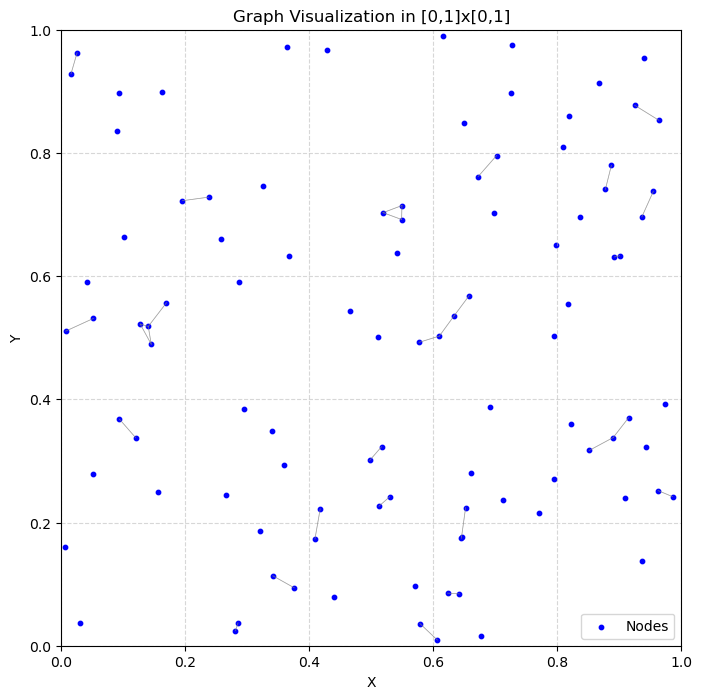

In [32]:
import matplotlib.pyplot as plt

def visualize_graph(node_coords, edges):
    """
    Visualize the graph in the [0,1]x[0,1] unit square.
    """
    plt.figure(figsize=(8, 8))
    
    # Plot edges
    for edge in edges:
        i, j = edge
        x_coords = [node_coords[i, 0], node_coords[j, 0]]
        y_coords = [node_coords[i, 1], node_coords[j, 1]]
        plt.plot(x_coords, y_coords, color='gray', alpha=0.5, linewidth=0.5)
    
    # Plot nodes
    plt.scatter(node_coords[:, 0], node_coords[:, 1], c='blue', s=10, label='Nodes')
    
    # Formatting
    plt.title("Graph Visualization in [0,1]x[0,1]")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

# Call the visualization function
visualize_graph(node_coords, edges)


In [ ]:
import numpy as np

def sample_and_display_probabilities(probabilities, X, characteristic_idx):
    """
    Sample X random nodes and display their probability distributions
    for a given characteristic.
    
    Parameters:
        probabilities (list): List of length J, where each element is an (N, k_j) array
                              of categorical probabilities for each characteristic.
        X (int): Number of random nodes to sample.
        characteristic_idx (int): Index of the characteristic to analyze.
    """
    N = probabilities[characteristic_idx].shape[0]
    k_j = probabilities[characteristic_idx].shape[1]
    
    if X > N:
        raise ValueError(f"Cannot sample {X} nodes; only {N} nodes available.")
    
    # Randomly sample X nodes
    sampled_indices = np.random.choice(N, size=X, replace=False)
    
    # Display probability distributions
    print(f"Probability distributions for Characteristic {characteristic_idx}:")
    for node_idx in sampled_indices:
        prob_dist = probabilities[characteristic_idx][node_idx]
        print(f"Node {node_idx}: {prob_dist}")

sample_and_display_probabilities(probabilities, 10, 0)

In [ ]:
import matplotlib.pyplot as plt

def visualize_node_and_neighbors(node_idx, adjacency_list, probabilities, characteristic_idx):
    """
    Visualize the probability distributions for a given node and its directly adjacent nodes.
    
    Parameters:
        node_idx (int): The node whose probabilities and neighbors to visualize.
        adjacency_list (list of lists): Adjacency list representing the graph.
        probabilities (list): List of length J, where each element is an (N, k_j) array
                              of categorical probabilities for each characteristic.
        characteristic_idx (int): Index of the characteristic to analyze.
    """
    # Get neighbors from adjacency list
    neighbors = [j for j in adjacency_list[node_idx]]
    nodes_to_plot = [node_idx] + neighbors  # Include the node itself
    
    # Get probabilities for the characteristic
    prob_matrix = probabilities[characteristic_idx]
    k_j = prob_matrix.shape[1]  # Number of groups
    
    # Visualize probabilities as a bar plot
    plt.figure(figsize=(10, 6))
    bar_width = 0.8 / len(nodes_to_plot)  # Narrower bars for multiple nodes
    
    for i, node in enumerate(nodes_to_plot):
        prob_dist = prob_matrix[node]
        x = np.arange(k_j) + i * bar_width  # Offset bars for each node
        plt.bar(x, prob_dist, width=bar_width, label=f"Node {node}")
    
    # Formatting
    plt.title(f"Probability Distributions for Node {node_idx} and Neighbors")
    plt.xlabel("Groups")
    plt.ylabel("Probability")
    plt.xticks(np.arange(k_j), [f"Group {i}" for i in range(k_j)])
    plt.legend()
    plt.show()


# Create adjacency list from edges
adjacency_list = [[] for _ in range(len(node_coords))]
for i, j in edges:
    adjacency_list[i].append(j)

node_idx = 0  # Node to analyze
characteristic_idx = 0  # Characteristic to visualize

# Visualize distributions for the node and its neighbors
visualize_node_and_neighbors(node_idx, adjacency_list, probabilities, characteristic_idx)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def compare_distributions_across_clusters(
    node_coords, clusters, adjacency_list, probabilities, characteristic_idx
):
    """
    Compare the probability distributions between a random node in one cluster and its neighbors,
    and a random node in another cluster and its neighbors.
    
    Parameters:
        node_coords (numpy.ndarray): Coordinates of nodes (N, 2).
        clusters (numpy.ndarray): Cluster assignments for nodes (N,).
        adjacency_list (list of lists): Adjacency list representing the graph.
        probabilities (list): List of length J, where each element is an (N, k_j) array
                              of categorical probabilities for each characteristic.
        characteristic_idx (int): Index of the characteristic to analyze.
    """
    # Identify unique clusters
    unique_clusters = np.unique(clusters)
    if len(unique_clusters) < 2:
        raise ValueError("There must be at least two clusters to compare.")
    
    # Select one random node from each cluster
    cluster_nodes = {cluster: np.where(clusters == cluster)[0] for cluster in unique_clusters}
    selected_nodes = {cluster: np.random.choice(nodes) for cluster, nodes in cluster_nodes.items()}
    
    # For each selected node, gather its neighbors
    nodes_to_plot = {}
    for cluster, node in selected_nodes.items():
        neighbors = adjacency_list[node]
        nodes_to_plot[cluster] = [node] + neighbors  # Include the node itself
    
    # Get probabilities for the characteristic
    prob_matrix = probabilities[characteristic_idx]
    k_j = prob_matrix.shape[1]  # Number of groups
    
    # Visualize distributions
    plt.figure(figsize=(12, 6))
    bar_width = 0.8 / len(nodes_to_plot)  # Narrower bars for multiple nodes
    
    for cluster_idx, (cluster, nodes) in enumerate(nodes_to_plot.items()):
        offset = cluster_idx * (k_j + 1)  # Space out clusters
        for i, node in enumerate(nodes):
            prob_dist = prob_matrix[node]
            x = np.arange(k_j) + offset + i * bar_width  # Offset bars for each node
            plt.bar(
                x,
                prob_dist,
                width=bar_width,
                label=f"Cluster {cluster}, Node {node}" if i == 0 else f"Node {node}",
            )
    
    # Formatting
    plt.title(
        f"Probability Distributions Comparison for Characteristic {characteristic_idx}"
    )
    plt.xlabel("Groups")
    plt.ylabel("Probability")
    plt.xticks(
        np.arange(len(unique_clusters) * (k_j + 1))[: len(unique_clusters) * k_j],
        [f"Group {i}" for i in range(k_j)] * len(unique_clusters),
    )
    plt.legend()
    plt.show()
    
clusters = np.array([np.argmin(np.linalg.norm(node_coords[i] - centers, axis=1)) for i in range(len(node_coords))])
# Create adjacency list from edges
adjacency_list = [[] for _ in range(len(node_coords))]
for i, j in edges:
    adjacency_list[i].append(j)

# Compare distributions for Characteristic 0
compare_distributions_across_clusters(node_coords, clusters, adjacency_list, probabilities, characteristic_idx=0)




In [ ]:
improved_compare_distributions_across_clusters(
    node_coords=node_coords,
    clusters=clusters,
    adjacency_list=adjacency_list,
    probabilities=probabilities,
    characteristic_idx=0,  # Analyze Characteristic 0
    max_neighbors=3,  # Show up to 3 neighbors per cluster
)


In [35]:
from scipy.spatial.distance import euclidean
from scipy.spatial import distance_matrix

def compare_distributions_by_distance(node_coords, probabilities, characteristic_idx, distance_threshold):
    """
    Compare demographic characteristic distributions for nodes based on their proximity.
    
    Parameters:
        node_coords (numpy.ndarray): Coordinates of nodes (N, 2).
        probabilities (list): List of length J, where each element is an (N, k_j) array
                              of categorical probabilities for each characteristic.
        characteristic_idx (int): Index of the characteristic to analyze.
        distance_threshold (float): Threshold to define "close" vs "far" nodes.
        
    Returns:
        dict: Average similarity for "close" and "far" node pairs.
    """
    N = len(node_coords)
    
    # Get the probability distributions for the specified characteristic
    prob_matrix = probabilities[characteristic_idx]
    
    # Compute pairwise distances
    dist_matrix = distance_matrix(node_coords, node_coords)
    
    # Lists to store similarity scores
    close_similarities = []
    far_similarities = []
    
    # Compare distributions for all pairs of nodes
    for i in range(N):
        for j in range(i + 1, N):  # Avoid duplicate comparisons
            dist = dist_matrix[i, j]
            prob_i = prob_matrix[i]
            prob_j = prob_matrix[j]
            
            # Use a similarity measure (e.g., Euclidean distance or cosine similarity)
            similarity = 1 - euclidean(prob_i, prob_j)  # Inverted Euclidean distance as similarity
            
            if dist <= distance_threshold:
                close_similarities.append(similarity)
            else:
                far_similarities.append(similarity)
    
    # Compute averages
    avg_close_similarity = np.mean(close_similarities) if close_similarities else 0
    avg_far_similarity = np.mean(far_similarities) if far_similarities else 0
    
    return {
        "avg_close_similarity": avg_close_similarity,
        "avg_far_similarity": avg_far_similarity,
        "close_count": len(close_similarities),
        "far_count": len(far_similarities),
    }

# Example parameters
distance_threshold = 0.1  # Nodes within 0.1 are considered "close"
characteristic_idx = 0    # Analyze Characteristic 0

# Compare distributions by distance
results = compare_distributions_by_distance(node_coords, probabilities, characteristic_idx, distance_threshold)

# Print results
print("Average Similarity for Close Nodes:", results["avg_close_similarity"])
print("Average Similarity for Far Nodes:", results["avg_far_similarity"])
print("Number of Close Node Pairs:", results["close_count"])
print("Number of Far Node Pairs:", results["far_count"])


Average Similarity for Close Nodes: 0.9085324842546773
Average Similarity for Far Nodes: 0.5385843078574899
Number of Close Node Pairs: 155
Number of Far Node Pairs: 4795
